# Laser Point Detection with OpenCV

Detect a laser point in a single image using HSV color filtering and contour analysis.

This notebook supports red and green laser points and returns pixel coordinates for the detected spot.

In [2]:
# If needed, uncomment to install dependencies in the notebook kernel:
# %pip install opencv-python numpy matplotlib

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt



In [8]:
# Laser detection from a saved video file using logic inspired by laser_tracker.py (detection only).
VIDEO_PATH = Path(r"C:\Users\aram\Downloads\test1.mp4")
image_path = Path(r"C:\Users\aram\Downloads\test1.png")

image_gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if image_gray is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

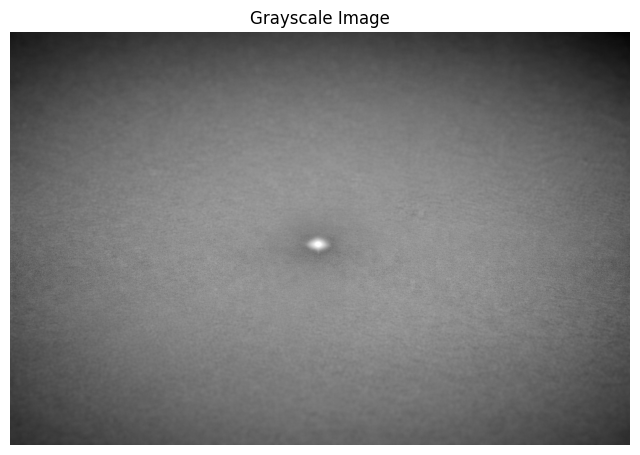

In [9]:
plt.figure(figsize=(8, 6))
plt.imshow(image_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Brightest point coordinates: (758, 524)
Brightest point intensity: 254


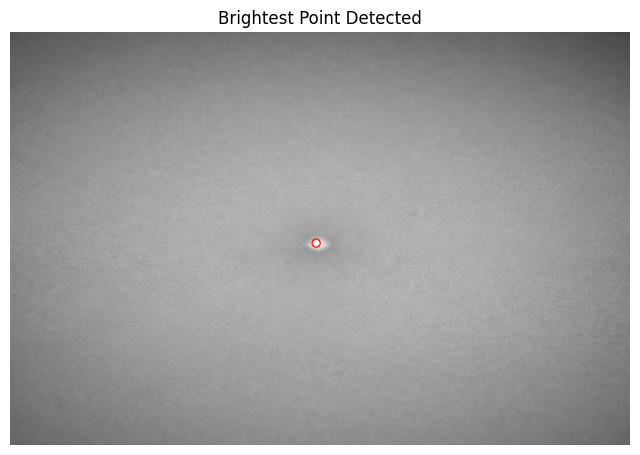

In [11]:
brightest_point = cv2.minMaxLoc(image_gray)[3]
print("Brightest point coordinates:", brightest_point)
print("Brightest point intensity:", image_gray[brightest_point[1], brightest_point[0]])
image_vis = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)
cv2.circle(image_vis, brightest_point, 10, (255, 0, 0), 2)

plt.figure(figsize=(8, 6))
plt.imshow(image_vis)
plt.title("Brightest Point Detected")
plt.axis("off")
plt.show()

In [12]:
# Load the video
cap = cv2.VideoCapture(str(VIDEO_PATH))
#convert the video to grayscale 
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    brightest_point = cv2.minMaxLoc(gray_frame)[3]
    cv2.circle(frame, brightest_point, 10, (0, 255, 0), 2)
    cv2.imshow("Laser Detection", frame)
    if cv2.waitKey(30) & 0xFF == ord("q"):
        break
cap.release()
cv2.destroyAllWindows()

In [19]:

def detect_laser_points(frame):
    # Convert the frame to HSV color space for better color segmentation
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # Define the lower and upper bounds for the laser color (red in this case)
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    
    # Create masks for the red color
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = cv2.bitwise_or(mask1, mask2)
    
    # Find contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    laser_points = []
    for contour in contours:
        if cv2.contourArea(contour) > 5:  # Filter small contours
            M = cv2.moments(contour)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                laser_points.append((cX, cY))
                # Draw a circle around the detected laser point
                cv2.circle(frame, (cX, cY), 5, (0, 255, 0), -1)
    
    return laser_points


Text(0.5, 1.0, 'Detected Laser Points')

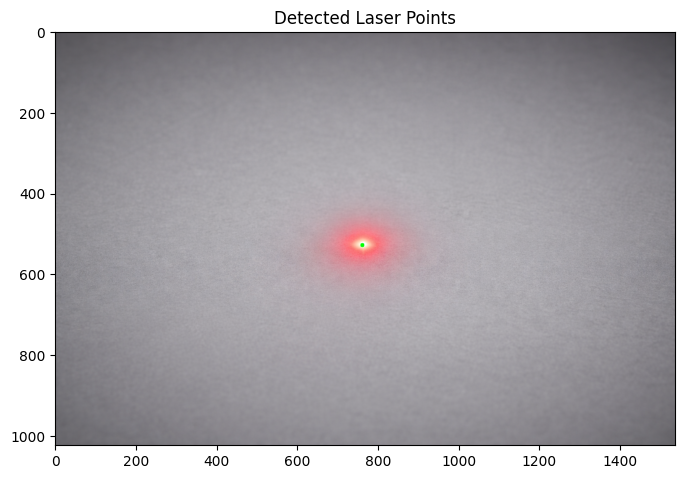

In [24]:
frame=cv2.imread(image_path)
smoothed_points = detect_laser_points(frame)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Detected Laser Points")

In [7]:
#apply the detection on the video frames
cap = cv2.VideoCapture(str(VIDEO_PATH))
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    detect_laser_points(frame)
    cv2.imshow('Laser Detection', frame)
    #wait 2 seconds before showing the next frame
    cv2.waitKey(200)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()
